# Email Spam Classification Using Natural Language Processing and Machine Learning

**Minor Project — B.Tech CSE (AI Specialization), Semester 1**

A beginner-friendly, end-to-end machine learning project that classifies email/SMS messages as **SPAM** or **NOT SPAM (HAM)** using **TF-IDF** feature extraction and a **Multinomial Naive Bayes** classifier.

> Run the cells in order, from top to bottom. No manual downloads, API keys, or file uploads are required.


## 1. Project Overview

Spam messages (unwanted, unsolicited, or fraudulent messages) are a common problem in email and SMS systems. This project builds a simple **text classification** system that automatically learns, from a labelled dataset of past messages, how to tell spam messages apart from genuine ("ham") ones.

The pipeline is:

1. Load a labelled spam/ham dataset.
2. Clean and pre-process the text.
3. Convert text into numeric features using **TF-IDF**.
4. Train a **Multinomial Naive Bayes** classifier.
5. Evaluate the model with standard classification metrics.
6. Provide an interactive cell where you can type your own message and get a live prediction.


## 2. Problem Statement

Given a message (email or SMS) written in free-form natural language, automatically predict whether the message is:

- **Spam** — an unwanted/promotional/fraudulent message, or
- **Ham** — a genuine, legitimate message.

This is framed as a **binary text classification** problem and solved using classical NLP + Machine Learning techniques (as opposed to deep learning), which keeps the project lightweight, fast to train, and easy to explain in a viva.


## 3. Objectives

- To understand and implement a basic **NLP text pre-processing pipeline**.
- To understand and apply **TF-IDF** for converting text into numerical features.
- To train and evaluate a **Multinomial Naive Bayes** classifier for spam detection.
- To evaluate the model using Accuracy, Precision, Recall, F1-score and a Confusion Matrix.
- To build a simple interactive demo that classifies a user-typed message in real time.


## 4. Technologies Used

| Category | Tool / Library |
|---|---|
| Language | Python 3 |
| Environment | Google Colab (Jupyter Notebook) |
| Data handling | pandas, numpy |
| NLP / Feature Extraction | scikit-learn `TfidfVectorizer`, Python `re` (regex) |
| Machine Learning | scikit-learn `MultinomialNB` |
| Evaluation | scikit-learn `metrics` |
| Visualization | matplotlib, seaborn |

All of the above are **pre-installed in Google Colab** — no `pip install` or API key is required.


## 5. Import Libraries

All libraries used in this notebook are part of the standard Google Colab environment.

In [19]:
# Core data handling
import numpy as np
import pandas as pd

# Text preprocessing
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Nicer plots
sns.set(style="whitegrid")

print("All libraries imported successfully.")


All libraries imported successfully.


## 6. Dataset Acquisition

This project uses the well-known **SMS Spam Collection** dataset (5,574 real, English-language SMS messages labelled `ham` or `spam`). It is widely used as a stand-in for general email/message spam classification in academic projects.

The notebook first tries to download the dataset automatically from a stable public GitHub source. **If, for any reason, the download does not work** (e.g. no internet access in the runtime), the notebook automatically falls back to a smaller, self-contained dataset that is written directly into the code below — so the notebook will run successfully either way, with no manual upload needed.


In [20]:
# Try to automatically download a well-known public spam/ham dataset.
# If the download fails for any reason, fall back to a small built-in dataset
# so the notebook still runs end-to-end without any manual file upload.

DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

def load_fallback_dataset():
    """A small, self-contained spam/ham dataset used only if the
    online download is not available. This keeps the notebook fully
    runnable even without internet access."""
    data = {
        "label": (
            ["spam"] * 25 + ["ham"] * 25
        ),
        "message": [
            # ---- SPAM examples ----
            "Congratulations! You have won a $1000 Walmart gift card. Click here to claim now.",
            "URGENT! Your mobile number has won 2,000 pounds. Call now to claim your prize.",
            "Free entry into our weekly competition. Text WIN to 80086 now!",
            "You have been selected for a free cruise to the Bahamas. Reply YES to claim.",
            "WINNER!! As a valued customer you have been selected to receive a free gift.",
            "Get cheap loans instantly approved, no credit check required, apply now!",
            "Click this link to claim your free iPhone before it expires today.",
            "Congratulations, you have been chosen to receive a cash reward of $5000.",
            "Limited time offer! Buy one get one free on all products, click now.",
            "Your account has been suspended. Verify your details immediately to avoid closure.",
            "You have won a lottery of 1,000,000 dollars. Send your bank details to claim.",
            "Hot singles in your area are waiting to chat with you, click here now.",
            "Earn $500 per day working from home, no experience needed, sign up today.",
            "FREE ringtone waiting for you, reply with your favourite song title now.",
            "Congratulations, your loan of $10000 has been approved, claim it now.",
            "URGENT: Your bank account will be locked. Click here to verify your identity.",
            "You've been selected for a free trial, no payment info needed, act now.",
            "Get rich quick with this one simple trick, doctors hate it, click now.",
            "Claim your free vacation package now before this offer expires tonight.",
            "Text STOP to unsubscribe or continue to receive amazing cash prizes weekly.",
            "You are pre-approved for a credit card with 0% interest, apply immediately.",
            "Win a brand new car by entering our free prize draw today only.",
            "Your prize of 500 dollars is waiting, call this number to claim it now.",
            "Exclusive deal just for you, 90% off, limited stock, buy now before it's gone.",
            "Congratulations! You've been chosen for a free gift card worth $100, click here.",
            # ---- HAM examples ----
            "Hey, are we still meeting for lunch tomorrow at noon?",
            "Please find attached the report you asked for yesterday.",
            "Can you send me the notes from today's class when you get a chance?",
            "Happy birthday! Hope you have a wonderful day with your family.",
            "I'll be running about ten minutes late, sorry for the delay.",
            "Let's catch up this weekend, it has been a while since we talked.",
            "The meeting has been rescheduled to 3 PM on Thursday, please confirm.",
            "Thanks for helping me move last weekend, I really appreciate it.",
            "Don't forget to bring your laptop charger to the workshop tomorrow.",
            "I just finished the assignment, will share it with you shortly.",
            "Mom said dinner will be ready by 8, come home soon.",
            "Can we reschedule our call to tomorrow morning instead of today?",
            "Great job on the presentation today, the client seemed impressed.",
            "I left my notebook at your place, can I come pick it up later?",
            "Let me know once you reach home safely, drive carefully.",
            "The project deadline has been extended to next Friday.",
            "I booked the tickets for the movie tonight, see you at 7.",
            "Please review the attached document and share your feedback.",
            "Congratulations on your new job, wishing you all the best!",
            "Are you free this evening for a quick call about the project?",
            "The wifi at the office is down, working from home today.",
            "I have submitted the assignment, please check and confirm receipt.",
            "Let's plan a trip together during the semester break this year.",
            "Thanks for the birthday wishes, it means a lot to me.",
            "Could you please share the class notes from Monday's lecture?",
        ],
    }
    return pd.DataFrame(data)

try:
    raw_df = pd.read_csv(DATA_URL, sep="\t", header=None, names=["label", "message"])
    if raw_df.empty:
        raise ValueError("Downloaded dataset is empty.")
    print("Dataset downloaded successfully from the public source.")
    print("Source URL:", DATA_URL)
except Exception as e:
    print("Could not download the dataset automatically. Reason:", e)
    print("Using the built-in fallback dataset instead so the notebook can still run.")
    raw_df = load_fallback_dataset()

print("Dataset shape:", raw_df.shape)
raw_df.head()


Dataset downloaded successfully from the public source.
Source URL: https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 7. Dataset Inspection

Before cleaning the data, let's take a quick look at its structure, size, and class balance.

In [21]:
print("Number of rows and columns:", raw_df.shape)
print()
print("Column names:", list(raw_df.columns))
print()
print("Data types:")
print(raw_df.dtypes)
print()
print("Missing values per column:")
print(raw_df.isnull().sum())
print()
print("Class distribution (label column):")
print(raw_df["label"].value_counts())


Number of rows and columns: (5572, 2)

Column names: ['label', 'message']

Data types:
label      object
message    object
dtype: object

Missing values per column:
label      0
message    0
dtype: int64

Class distribution (label column):
label
ham     4825
spam     747
Name: count, dtype: int64


## 8. Data Cleaning

We now:
- Keep only the two columns we actually need: `label` and `message`.
- Drop rows with missing/empty labels or messages.
- Remove exact duplicate messages, which can otherwise bias the model.
- Convert the text label (`spam` / `ham`) into a numeric label (`1` / `0`) that scikit-learn can work with.


In [22]:
# Keep only the relevant columns (works whether the source dataset has extra
# unnamed columns or not, since we already selected label/message above).
df = raw_df[["label", "message"]].copy()

# Standardize the label text (lowercase, strip spaces) before mapping
df["label"] = df["label"].astype(str).str.strip().str.lower()

# Drop rows with missing message or label
df = df.dropna(subset=["label", "message"])

# Keep only rows where label is exactly 'spam' or 'ham'
df = df[df["label"].isin(["spam", "ham"])]

# Remove exact duplicate messages
df = df.drop_duplicates(subset=["message"])

# Reset index after dropping rows
df = df.reset_index(drop=True)

# Map text labels to numeric labels: ham -> 0, spam -> 1
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

print("Shape after cleaning:", df.shape)
print()
print("Class distribution after cleaning:")
print(df["label"].value_counts())
df.head()


Shape after cleaning: (5169, 3)

Class distribution after cleaning:
label
ham     4516
spam     653
Name: count, dtype: int64


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 9. Exploratory Data Analysis (EDA)

A quick visual look at the dataset before modelling:

1. **Class distribution** — how many spam vs ham messages we have.
2. **Message length distribution** — do spam messages tend to be longer or shorter than ham messages?


/tmp/ipykernel_2255/4128422617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", order=["ham", "spam"], palette="viridis")


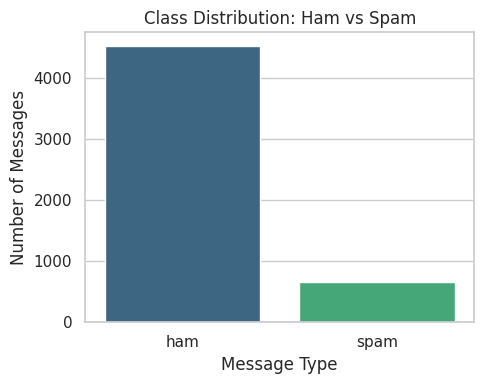

In [23]:
# 1. Spam vs Ham class distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label", order=["ham", "spam"], palette="viridis")
plt.title("Class Distribution: Ham vs Spam")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.show()


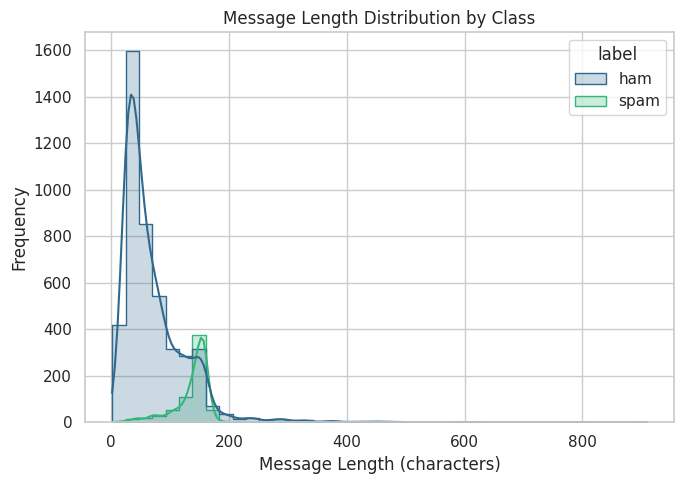

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.905890  56.715046   2.0   34.0   53.0   91.0  910.0
spam    653.0  137.704441  29.821348  13.0  132.0  148.0  157.0  223.0


In [24]:
# 2. Message length distribution (in characters), split by class
df["message_length"] = df["message"].apply(len)

plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="message_length", hue="label", bins=40, kde=True, palette="viridis", element="step")
plt.title("Message Length Distribution by Class")
plt.xlabel("Message Length (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df.groupby("label")["message_length"].describe())


## 10. Text Preprocessing

Raw text needs to be cleaned before it can be turned into useful numeric features. Our preprocessing pipeline performs simple, safe operations:

1. Convert text to **lowercase** (so "FREE" and "free" are treated the same).
2. Remove **URLs** and **email addresses** (they add noise as raw text).
3. Remove **punctuation and numbers** that don't carry much meaning on their own for this simple model.
4. Collapse **extra whitespace** into single spaces.
5. Handle empty results safely (a message that becomes empty after cleaning is kept as an empty string, not dropped, so indexes stay aligned).

We deliberately keep this pipeline simple (no aggressive stemming/lemmatization) so that the text still contains enough information for TF-IDF to work well, per the project requirement to avoid over-processing.


In [25]:
def preprocess_text(text):
    """Clean a single message: lowercase, remove URLs/emails/punctuation/
    numbers, and collapse extra whitespace. Always returns a string,
    even for missing or non-string input, so it never crashes."""
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove standalone digits (keep words made of letters)
    text = re.sub(r"\d+", " ", text)

    # Collapse multiple spaces/newlines/tabs into a single space
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply preprocessing to every message in the dataset
df["clean_message"] = df["message"].apply(preprocess_text)

# Show a few before/after examples
df[["message", "clean_message"]].head(10)


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


## 11. TF-IDF Feature Extraction

Machine learning models work with numbers, not raw text, so we need to convert each cleaned message into a numeric vector.

**What is TF-IDF (in simple terms)?**

- **TF (Term Frequency)**: how often a word appears in a given message. A word that appears many times in one message is probably important to that message.
- **IDF (Inverse Document Frequency)**: how *rare* a word is across *all* messages. Common words like "the" or "is" appear everywhere and are not very useful for telling messages apart, so they get a low score. Rarer, more distinctive words (like "prize" or "winner") get a higher score.
- **TF-IDF = TF × IDF**: a word gets a high TF-IDF score in a message if it appears often *in that message* but is *rare across the whole dataset* — exactly the kind of word that's useful for distinguishing spam from ham.

We use scikit-learn's `TfidfVectorizer`, which converts every message into a vector of TF-IDF scores (one score per word in the vocabulary).


In [26]:
# Convert the cleaned text into TF-IDF feature vectors.
# - stop_words='english' removes very common English words (the, is, and, ...)
# - max_features limits the vocabulary size to the most informative words,
#   which keeps the model fast and avoids overfitting on rare words.
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)

print("TF-IDF vectorizer created successfully.")


TF-IDF vectorizer created successfully.


## 12. Train-Test Split

We split the dataset into a **training set** (used to teach the model) and a **testing set** (used to check how well the model performs on messages it has never seen before).

- 80% of the data is used for training.
- 20% of the data is used for testing.
- `random_state=42` ensures the split is reproducible — running the notebook again gives the same split.
- `stratify=df['label_num']` keeps the spam/ham ratio the same in both the training and testing sets.


In [27]:
X = df["clean_message"]
y = df["label_num"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training samples:", X_train_text.shape[0])
print("Testing samples:", X_test_text.shape[0])


Training samples: 4135
Testing samples: 1034


In [28]:
# Fit the TF-IDF vectorizer ONLY on the training data, then use it to
# transform both the training and testing data. This avoids "data leakage"
# (the model should never learn from information seen only in the test set).
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)

print("Shape of training feature matrix:", X_train.shape)
print("Shape of testing feature matrix:", X_test.shape)


Shape of training feature matrix: (4135, 3000)
Shape of testing feature matrix: (1034, 3000)


## 13. Naive Bayes Model

We use **Multinomial Naive Bayes (`MultinomialNB`)**, a simple probabilistic classifier that works especially well for text classification tasks with word-frequency-style features like TF-IDF.

In simple terms, Naive Bayes looks at how likely a set of words is to appear in spam messages versus ham messages (based on the training data) and then, for a new message, calculates which class is more probable given the words it contains. It's called "naive" because it assumes each word contributes independently to the prediction, which isn't strictly true in real language but works surprisingly well in practice for spam filtering.


In [29]:
# Create the Multinomial Naive Bayes model
nb_model = MultinomialNB()

print("Naive Bayes model created successfully.")


Naive Bayes model created successfully.


## 14. Model Training

We now train (fit) the model on the TF-IDF features of the training data.

In [30]:
nb_model.fit(X_train, y_train)
print("Model training complete.")


Model training complete.


## 15. Predictions

Using the trained model to predict labels for the unseen test set.

In [31]:
y_pred = nb_model.predict(X_test)

# Show a few predictions vs actual values
results_preview = pd.DataFrame({
    "message": X_test_text.values[:10],
    "actual": y_test.values[:10],
    "predicted": y_pred[:10],
})
results_preview["actual"] = results_preview["actual"].map({0: "ham", 1: "spam"})
results_preview["predicted"] = results_preview["predicted"].map({0: "ham", 1: "spam"})
results_preview


,message,actual,predicted
0,good morning my love i go to sleep now and wis...,ham,ham
1,and how you will do that princess,ham,ham
2,cool ill text you when im on the way,ham,ham
3,your right ill make the appointment right now,ham,ham
4,aiya we discuss later lar pick ü up at is it,ham,ham
5,maybe say hi to and find out if got his card g...,ham,ham
6,lemme know when i can swing by and pick up im ...,ham,ham
7,yes please leave at ltgt so that at ltgt we ca...,ham,ham
8,i am in bus on the way to calicut,ham,ham
9,o we cant see if we can join denis and mina or...,ham,ham


## 16. Model Evaluation

We evaluate the model using standard classification metrics:

- **Accuracy**: overall proportion of correct predictions.
- **Precision**: of all messages predicted as spam, how many were actually spam? (Important — we don't want genuine messages wrongly marked as spam.)
- **Recall**: of all actual spam messages, how many did the model correctly catch?
- **F1-score**: the harmonic mean of precision and recall — a single balanced score.

> **Note:** This is an educational project trained on a limited dataset. These metrics reflect performance on this specific dataset and test split only, and should not be interpreted as a claim about real-world spam-filter performance.


In [32]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 0.9749
Precision : 1.0000
Recall    : 0.8015
F1-score  : 0.8898


## 17. Confusion Matrix

The confusion matrix shows exactly how many messages of each true class were predicted into each class:

- **Top-left**: Ham correctly predicted as Ham (True Negative)
- **Top-right**: Ham wrongly predicted as Spam (False Positive)
- **Bottom-left**: Spam wrongly predicted as Ham (False Negative)
- **Bottom-right**: Spam correctly predicted as Spam (True Positive)


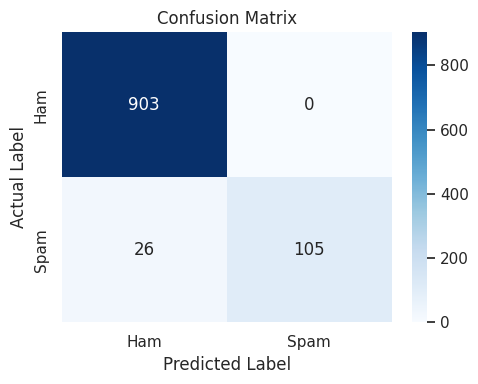

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


## 18. Classification Report

A combined summary of precision, recall, and F1-score for each class.

In [34]:
report = classification_report(y_test, y_pred, target_names=["Ham", "Spam"], zero_division=0)
print(report)


              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       903
        Spam       1.00      0.80      0.89       131

    accuracy                           0.97      1034
   macro avg       0.99      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034



## 19. Interactive Spam Detection

Run the cell below and type (or paste) any email/SMS-style message when prompted. The trained model will predict whether it is **SPAM** or **NOT SPAM**, along with the model's confidence (probability) for each class.

- Empty input is handled safely (it will simply be treated as "not enough information" without crashing the program).
- You can run this cell as many times as you like to try different messages.


In [35]:
def predict_message(message):
    """Take a raw message string, preprocess it, and return the prediction
    label plus class probabilities. Handles empty/invalid input safely."""
    if not isinstance(message, str) or message.strip() == "":
        return None, None

    cleaned = preprocess_text(message)

    if cleaned.strip() == "":
        # Nothing meaningful left after cleaning (e.g. message was just symbols)
        return None, None

    vectorized = tfidf_vectorizer.transform([cleaned])
    prediction = nb_model.predict(vectorized)[0]

    probabilities = None
    if hasattr(nb_model, "predict_proba"):
        probabilities = nb_model.predict_proba(vectorized)[0]

    return prediction, probabilities


def show_prediction(message):
    prediction, probabilities = predict_message(message)

    print("-" * 60)
    print("Input message:", repr(message))

    if prediction is None:
        print("Result: Could not classify - the input was empty or contained")
        print("        no usable text. Please enter a valid message.")
        print("-" * 60)
        return

    label = "SPAM" if prediction == 1 else "NOT SPAM"
    print("Prediction:", label)

    if probabilities is not None:
        print(f"Probability (Ham)  : {probabilities[0]:.4f}")
        print(f"Probability (Spam) : {probabilities[1]:.4f}")

    print("-" * 60)


# --- Try it yourself ---
# Type your own message inside the quotes below and re-run this cell,
# or use input() interactively (see the next cell).
sample_message = "Congratulations! You have won a prize. Click here to claim it."
show_prediction(sample_message)


------------------------------------------------------------
Input message: 'Congratulations! You have won a prize. Click here to claim it.'
Prediction: SPAM
Probability (Ham)  : 0.0161
Probability (Spam) : 0.9839
------------------------------------------------------------


In [36]:
# Interactive version: enter a message directly when prompted.
# Safe against empty input, keyboard interrupts, or unexpected errors --
# it will never crash the notebook.
try:
    user_message = input("Enter an email/SMS message to classify (or press Enter to skip): ")
    if user_message.strip() == "":
        print("No message entered - skipping interactive prediction.")
    else:
        show_prediction(user_message)
except Exception as e:
    print("Something went wrong while reading input:", e)


Enter an email/SMS message to classify (or press Enter to skip): Congratulations! You have won a free cash prize of $1000. Click now to claim your reward!
------------------------------------------------------------
Input message: 'Congratulations! You have won a free cash prize of $1000. Click now to claim your reward!'
Prediction: SPAM
Probability (Ham)  : 0.0082
Probability (Spam) : 0.9918
------------------------------------------------------------


## 20. Example Predictions

A few more example messages to demonstrate the model on both spam-like and ham-like text.

In [37]:
example_messages = [
    "Congratulations! You've won a free iPhone. Click the link now to claim your prize.",
    "Hi, are we still on for coffee tomorrow morning at 9?",
    "URGENT: Your account will be suspended, verify your password immediately.",
    "Don't forget to bring the project report to class tomorrow.",
    "You have been selected for a cash reward of $5000, reply now to claim.",
    "Mom, I'll be home by 7 for dinner, love you.",
]

for msg in example_messages:
    show_prediction(msg)


------------------------------------------------------------
Input message: "Congratulations! You've won a free iPhone. Click the link now to claim your prize."
Prediction: SPAM
Probability (Ham)  : 0.0352
Probability (Spam) : 0.9648
------------------------------------------------------------
------------------------------------------------------------
Input message: 'Hi, are we still on for coffee tomorrow morning at 9?'
Prediction: NOT SPAM
Probability (Ham)  : 0.9845
Probability (Spam) : 0.0155
------------------------------------------------------------
------------------------------------------------------------
Input message: 'URGENT: Your account will be suspended, verify your password immediately.'
Prediction: SPAM
Probability (Ham)  : 0.2167
Probability (Spam) : 0.7833
------------------------------------------------------------
------------------------------------------------------------
Input message: "Don't forget to bring the project report to class tomorrow."
Prediction:

## 21. Limitations

- The model is trained on a relatively small, English-language SMS dataset; it may not generalize well to very different writing styles, languages, or modern email spam patterns (e.g. long HTML emails, phishing with attachments).
- Multinomial Naive Bayes assumes word independence, which is a simplification of real language.
- The fallback dataset (used only if the online download fails) is very small and is meant purely to keep the notebook runnable, not to produce a high-accuracy production model.
- This project does not use email headers, sender reputation, attachments, or links analysis — only the message text itself.
- The reported metrics reflect performance on this specific dataset and test split, and should not be treated as a general claim about real-world spam-filtering accuracy.


## 22. Future Scope

- Use a larger and more diverse dataset that includes modern phishing/email spam examples.
- Experiment with other classifiers (Logistic Regression, SVM, Random Forest) and compare results.
- Add more advanced NLP techniques such as lemmatization, n-grams, or word embeddings (Word2Vec, GloVe, BERT).
- Incorporate additional features beyond text, such as sender information, number of links, or attachment types.
- Deploy the trained model as a simple web application or browser extension for real-time spam filtering.


## 23. Conclusion

This project successfully demonstrates a complete, beginner-friendly pipeline for email/SMS spam classification using classical NLP and Machine Learning techniques. Starting from raw text, the notebook performs cleaning and preprocessing, extracts meaningful numeric features using TF-IDF, trains a Multinomial Naive Bayes classifier, and evaluates it using standard metrics along with clear visualizations. The interactive section allows real-time testing of custom messages, making the concepts tangible. While simple, this project lays a solid foundation for understanding how real-world spam filters work and can be extended with more advanced techniques in the future.


---
### End of Notebook

*Prepared as an individual minor internship project — Email Spam Classification Using Natural Language Processing and Machine Learning.*
